# Phase 06A — Shared CORE MT layer

Đây là điểm bắt đầu mới của Phase 06. Notebook chỉ xây và kiểm tra các thành phần chung cho OPUS-MT, EnViT5 và M2M-100; chưa có adapter, checkpoint hoặc inference riêng cho model nào.

In [1]:
from pathlib import Path
import subprocess
import sys

import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / 'configs').is_dir():
    ROOT = ROOT.parents[1]
sys.path.insert(0, str(ROOT / 'src'))

from core_mt.contracts import Direction
from core_mt.data import load_locked_evaluation_set
from core_mt.protocol import load_frozen_protocol

print(f'Project root: {ROOT}')

Project root: C:\Users\ADMIN\ENVI-IT-MT


## Vì sao có các file `.py` này?

Notebook là nơi trình bày và chạy thí nghiệm. Các module `.py` là implementation tái sử dụng được; mỗi module tự chứa ghi chú về vai trò nghiên cứu của nó. Cell dưới hiển thị trực tiếp các ghi chú đó.

In [2]:
from IPython.display import Markdown, display
import core_mt.contracts as contracts_module
import core_mt.protocol as protocol_module
import core_mt.data as data_module
import core_mt.artifacts as artifacts_module

for name, module in {
    'contracts.py': contracts_module,
    'protocol.py': protocol_module,
    'data.py': data_module,
    'artifacts.py': artifacts_module,
}.items():
    display(Markdown(f'### `{name}`'))
    display(Markdown(module.__doc__.strip()))

### `contracts.py`

Hợp đồng dữ liệu giữa shared layer và các nhánh model.

`Direction` chuẩn hóa hai phép dịch EN→VI và VI→EN. `TranslationAdapter` mô
tả tối thiểu một model sau này phải làm được: tải một checkpoint, nhận câu
nguồn với generation settings chung, và trả về prediction thô. Nhờ hợp đồng
này, runner chung không cần biết OPUS-MT dùng prefix, EnViT5 dùng text prompt
hay M2M-100 dùng language code.

### `protocol.py`

Đọc luật đánh giá đã khóa trước baseline.

Trong nghiên cứu so sánh, cùng dataset nhưng beam size hoặc batch size khác
nhau đã đủ làm kết quả không còn công bằng. Vì vậy module này chuyển file JSON
đã frozen thành các object bất biến và từ chối protocol sai trạng thái, sai hai
direction hoặc có thêm evaluation set ngoài General Test và IT Test.

### `data.py`

Cổng dữ liệu cho baseline trước domain adaptation.

Phase 06 chỉ được nhìn General Test và IT Test. Thay vì trông chờ người chạy
tự nhớ quy tắc này, `_RELEASED_PATHS` là whitelist: tên `train` và `validation`
không có loader công khai. Module còn chuẩn hóa schema khác nhau của FLORES và
IT corpus về một `TestExample` có ID, English và Vietnamese.

### `artifacts.py`

Quy ước evidence có thể tái lập cho baseline run.

Mỗi model × direction sau này phải lưu cùng sáu artifact. `resolved_config`
giữ commit checkpoint và generation settings; `predictions` cho phép audit;
metric và benchmark luôn tách riêng. Không ghi đè thư mục run cũ vì một lần
chạy lại có thể dùng checkpoint cache, driver hoặc hardware khác.

## 1. Xác minh Phase 05 release gate

Không bắt đầu baseline nếu checksum manifest, General Test leakage hoặc frozen protocol không hợp lệ.

In [3]:
gate = subprocess.run(
    [sys.executable, str(ROOT / 'tools' / 'validate_phase05_gate.py')],
    cwd=ROOT, text=True, capture_output=True, check=False,
)
print(gate.stdout)
if gate.returncode:
    raise RuntimeError(gate.stderr or 'Phase 05 gate failed')

PHASE_05_GATE=PASS



## 2. Khóa protocol và evaluation input

Shared loader chỉ nhận `general_test` và `it_test`. IT `train` và `validation` không có API trong Phase 06A.

In [4]:
protocol = load_frozen_protocol(ROOT / 'configs' / 'evaluation_protocol_v2.json')
datasets = {name: load_locked_evaluation_set(name, ROOT) for name in protocol.evaluation_sets}

summary = pd.DataFrame([
    {
        'test_set': name,
        'parallel_pairs': len(dataset.rows),
        'path': dataset.path.relative_to(ROOT).as_posix(),
        'role': 'final evaluation only',
    }
    for name, dataset in datasets.items()
])
display(summary)
print({
    'protocol': protocol.protocol_version,
    'dataset_release': protocol.dataset_release,
    'seed': protocol.inference.seed,
    'num_beams': protocol.inference.num_beams,
    'batch_size': protocol.inference.batch_size,
    'quality_passes': protocol.benchmark.quality_passes,
    'latency_sample_size': protocol.benchmark.latency_sample_size,
    'warmup_sentences': protocol.benchmark.warmup_sentences,
    'latency_repeats': protocol.benchmark.latency_repeats,
})

,test_set,parallel_pairs,path,role
0,general_test,1012,data/processed/general_test_flores200_devtest_...,final evaluation only
1,it_test,13851,data/processed/it_en_vi_v1/it_test.jsonl,final evaluation only


{'protocol': 'core_mt_baseline_v2', 'dataset_release': 'phase05_release_v1', 'seed': 42, 'num_beams': 5, 'batch_size': 1, 'quality_passes': 1, 'latency_sample_size': 128, 'warmup_sentences': 32, 'latency_repeats': 5}


## 3. Trực quan hóa khối lượng dùng chung

Đây là khối lượng input cố định cho mọi model và mọi direction. Chưa có bất kỳ metric chất lượng nào ở bước này.

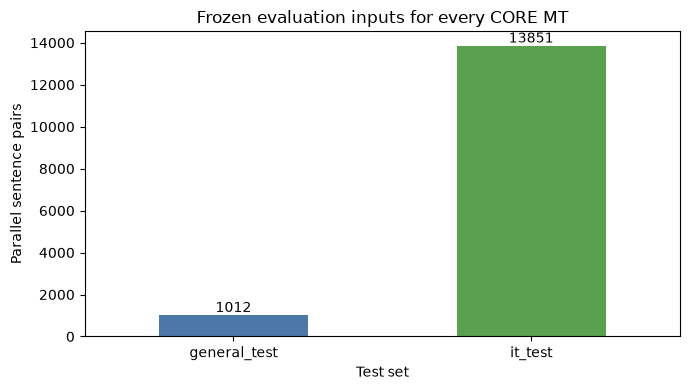

In [5]:
ax = summary.plot.bar(
    x='test_set', y='parallel_pairs', legend=False, rot=0, figsize=(7, 4),
    color=['#4c78a8', '#59a14f'], title='Frozen evaluation inputs for every CORE MT',
)
ax.set_xlabel('Test set')
ax.set_ylabel('Parallel sentence pairs')
for container in ax.containers:
    ax.bar_label(container, fmt='%d')
ax.figure.tight_layout()

## 4. Hợp đồng cho nhánh model sau này

Mỗi adapter tương lai chỉ phải quyết định checkpoint và cách chuẩn bị input. Các phần direction, test data, frozen generation settings và policy artifact đã được dùng chung.

In [6]:
for direction in Direction:
    print(f'{direction.value}: {direction.source_language} -> {direction.target_language}')

print('CORE_SHARED=READY')
print('MODEL_ADAPTERS=NOT_IMPLEMENTED')

en_to_vi: en -> vi
vi_to_en: vi -> en
CORE_SHARED=READY
MODEL_ADAPTERS=NOT_IMPLEMENTED
